<a href="https://colab.research.google.com/github/daaastis/fundamentals-of-data-mining/blob/main/%D0%90%D0%BD%D1%81%D0%B0%D0%BC%D0%B1%D0%BB%D0%B5%D0%B2%D0%B0%D1%8F_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ЭТАП 1: ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ CENSUS INCOME 
[Успешно] Размер датасета для ансамбля: (45222, 15)

 ЭТАП 2: ВЫЧИСЛЕНИЕ БАЗОВЫХ МЕТРИК ОДИНОЧНОГО ДЕРЕВА 
Базовое дерево (Accuracy): 0.8509
Базовое дерево (F1-Score):  0.6501

 ЭТАП 3: ЭКСПЕРИМЕНТЫ С АНСАМБЛЕМ (ВАРЬИРОВАНИЕ УЧАСТНИКОВ) 
╒══════════════════════════════════════╤════════════╤═════════════╤══════════╤════════════╕
│   Количество деревьев (n_estimators) │   Accuracy │   Precision │   Recall │   F1-Score │
╞══════════════════════════════════════╪════════════╪═════════════╪══════════╪════════════╡
│                                   50 │     0.8561 │      0.8127 │   0.5639 │     0.6658 │
├──────────────────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│                                   60 │     0.8559 │      0.8137 │   0.5622 │     0.665  │
├──────────────────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│                                   70 │     0.8555 │      0.8

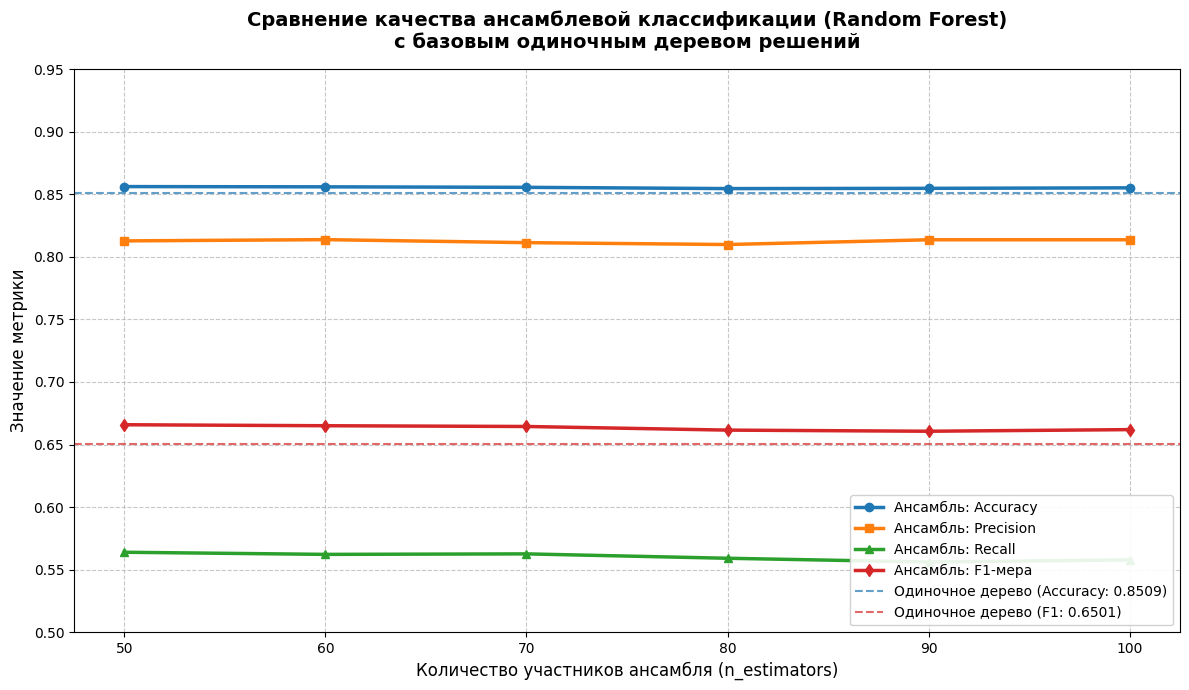

In [1]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# Установка tabulate для красивых таблиц в консоли
!pip install tabulate -q
from tabulate import tabulate

print("=" * 70)
print(" ЭТАП 1: ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ CENSUS INCOME ")
print("=" * 70)

train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

train_file = "adult.data"
test_file = "adult.test"

column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

if not os.path.exists(train_file):
    urllib.request.urlretrieve(train_url, train_file)
if not os.path.exists(test_file):
    urllib.request.urlretrieve(test_url, test_file)

df_train = pd.read_csv(train_file, names=column_names, skipinitialspace=True, na_values="?")
df_test = pd.read_csv(test_file, names=column_names, skiprows=1, skipinitialspace=True, na_values="?")

df_full = pd.concat([df_train, df_test], ignore_index=True).dropna()
df_full['income'] = df_full['income'].str.replace('.', '', regex=False)
df_full['income'] = df_full['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

for col in df_full.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_full[col] = le.fit_transform(df_full[col].astype(str))

print(f"[Успешно] Размер датасета для ансамбля: {df_full.shape}\n")

X = df_full.drop('income', axis=1)
y = df_full['income']

# Фиксируем единое разделение выборок (например, 80% обучение, 20% тест) для корректного сравнения
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, random_state=42)


# =================================================================
# 2. РАСЧЕТ БАЗОВОЙ МОДЕЛИ (ОДИНОЧНОЕ ДЕРЕВО РЕШЕНИЙ) ДЛЯ СРАВНЕНИЯ
# =================================================================
print("=" * 70)
print(" ЭТАП 2: ВЫЧИСЛЕНИЕ БАЗОВЫХ МЕТРИК ОДИНОЧНОГО ДЕРЕВА ")
print("=" * 70)

base_tree = DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)
base_tree.fit(X_train, y_train)
y_pred_tree = base_tree.predict(X_test)

tree_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tree),
    'Precision': precision_score(y_test, y_pred_tree, zero_division=0),
    'Recall': recall_score(y_test, y_pred_tree, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_tree, zero_division=0)
}

print(f"Базовое дерево (Accuracy): {tree_metrics['Accuracy']:.4f}")
print(f"Базовое дерево (F1-Score):  {tree_metrics['F1-Score']:.4f}\n")


# =================================================================
# 3. ЭКСПЕРИМЕНТЫ С АНСАМБЛЕМ (СЛУЧАЙНЫЙ ЛЕС / RANDOM FOREST)
# =================================================================
print("=" * 70)
print(" ЭТАП 3: ЭКСПЕРИМЕНТЫ С АНСАМБЛЕМ (ВАРЬИРОВАНИЕ УЧАСТНИКОВ) ")
print("=" * 70)

ensemble_sizes = list(range(50, 101, 10))  # от 50 до 100 с шагом 10
ensemble_results = []

for n_estimators in ensemble_sizes:
    # Инициализация ансамбля (Случайный лес - техника бэггинга)
    rf_model = RandomForestClassifier(n_estimators=n_estimators, criterion='entropy', max_depth=10, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    y_pred_rf = rf_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred_rf)
    prec = precision_score(y_test, y_pred_rf, zero_division=0)
    rec = recall_score(y_test, y_pred_rf, zero_division=0)
    f1 = f1_score(y_test, y_pred_rf, zero_division=0)

    ensemble_results.append({
        'Количество деревьев (n_estimators)': n_estimators,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

df_ensemble = pd.DataFrame(ensemble_results)
print(tabulate(df_ensemble, headers='keys', tablefmt='fancy_grid', showindex=False))
print()


# =================================================================
# 4. ВИЗУАЛИЗАЦИЯ (СРАВНИТЕЛЬНЫЕ ДИАГРАММЫ)
# =================================================================
print("=" * 70)
print(" ЭТАП 4: ПОСТРОЕНИЕ ДИАГРАММ СРАВНЕНИЯ КАЧЕСТВА ")
print("=" * 70)

plt.figure(figsize=(12, 7))

# Графики метрик ансамбля
plt.plot(ensemble_sizes, df_ensemble['Accuracy'], marker='o', label='Ансамбль: Accuracy', linewidth=2.5, color='#1f77b4')
plt.plot(ensemble_sizes, df_ensemble['Precision'], marker='s', label='Ансамбль: Precision', linewidth=2.5, color='#ff7f0e')
plt.plot(ensemble_sizes, df_ensemble['Recall'], marker='^', label='Ансамбль: Recall', linewidth=2.5, color='#2ca02c')
plt.plot(ensemble_sizes, df_ensemble['F1-Score'], marker='d', label='Ансамбль: F1-мера', linewidth=2.5, color='#d62728')

# Нанесение горизонтальных линий базового дерева решений для сравнения
plt.axhline(y=tree_metrics['Accuracy'], color='#1f77b4', linestyle='--', alpha=0.7, label=f"Одиночное дерево (Accuracy: {tree_metrics['Accuracy']:.4f})")
plt.axhline(y=tree_metrics['F1-Score'], color='#d62728', linestyle='--', alpha=0.7, label=f"Одиночное дерево (F1: {tree_metrics['F1-Score']:.4f})")

plt.title("Сравнение качества ансамблевой классификации (Random Forest)\nс базовым одиночным деревом решений", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Количество участников ансамбля (n_estimators)", fontsize=12)
plt.ylabel("Значение метрики", fontsize=12)
plt.ylim(0.5, 0.95)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()